# import libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import RobustScaler, FunctionTransformer
import os

# load data

In [22]:
xls = pd.ExcelFile("../data/dataset. AAC.xlsx")

sheet1 = xls.parse(xls.sheet_names[0]).drop(index=0).reset_index(drop=True)
sheet2 = xls.parse(xls.sheet_names[1]).drop(index=0).reset_index(drop=True)

inputs1 = sheet1.iloc[:, :-1].astype(float)
inputs2 = sheet2.iloc[:, :-1].astype(float)

output1 = sheet1.iloc[:, -1].astype(float).rename("Compressive_strength_MPa")
output2 = sheet2.iloc[:, -1].astype(float).rename("Mixture_CO2_kg")

sheet1_full = pd.concat([inputs1, output1], axis=1)
sheet2_full = pd.concat([inputs2, output2], axis=1)

df = pd.merge(sheet1_full, sheet2_full, on=list(inputs1.columns))

df.head(2)

,FA (kg/m3),GGBFS (kg/m3),Coarse aggregate (kg/m3),Fine aggregate (kg/m3),Na2SiO3,NaOH,Na2O (Dry),Sio2 (Dry),Water (1),Concentration (M) NaOH,...,NaOH (Dry),Additional water,Superplasticizer,Total water,Initial curing time (day),Initial curing temp (C),Initial curing rest time (day),Final curing temp (C),Compressive_strength_MPa,Mixture_CO2_kg
0,252.0,168.0,1010.929815,765.670185,180.000000,72.000000,20.70,54.00,105.300000,8.0,...,23.040000,0.0,16.8,164.340000,0.0,25.0,1.0,30.0,46.57,158.777280
1,264.0,176.0,969.460026,777.339974,188.571429,75.428571,21.69,56.57,110.314286,8.0,...,24.137143,0.0,17.6,172.165714,0.0,25.0,1.0,30.0,46.01,165.788983


In [23]:
df.columns

Index(['FA (kg/m3)', 'GGBFS (kg/m3)', 'Coarse aggregate (kg/m3)',
       'Fine aggregate (kg/m3)', 'Na2SiO3', 'NaOH', 'Na2O (Dry)', 'Sio2 (Dry)',
       'Water (1)', 'Concentration (M) NaOH', 'Water (2)', 'NaOH (Dry)',
       'Additional water', 'Superplasticizer', 'Total water',
       'Initial curing time (day)', 'Initial curing temp (C)',
       'Initial curing rest time (day)', 'Final curing temp (C)',
       'Compressive_strength_MPa', 'Mixture_CO2_kg'],
      dtype='object')

# analysis 

In [24]:
df.isnull().sum()

FA (kg/m3)                        0
GGBFS (kg/m3)                     0
Coarse aggregate (kg/m3)          0
Fine aggregate (kg/m3)            0
Na2SiO3                           0
NaOH                              0
Na2O (Dry)                        0
Sio2 (Dry)                        0
Water (1)                         0
Concentration (M) NaOH            0
Water (2)                         0
NaOH (Dry)                        0
Additional water                  0
Superplasticizer                  0
Total water                       0
Initial curing time (day)         0
Initial curing temp (C)           0
Initial curing rest time (day)    0
Final curing temp (C)             0
Compressive_strength_MPa          0
Mixture_CO2_kg                    0
dtype: int64

In [25]:
# correlation

In [26]:
corr = df.corr(numeric_only=True)
corr

,FA (kg/m3),GGBFS (kg/m3),Coarse aggregate (kg/m3),Fine aggregate (kg/m3),Na2SiO3,NaOH,Na2O (Dry),Sio2 (Dry),Water (1),Concentration (M) NaOH,...,NaOH (Dry),Additional water,Superplasticizer,Total water,Initial curing time (day),Initial curing temp (C),Initial curing rest time (day),Final curing temp (C),Compressive_strength_MPa,Mixture_CO2_kg
FA (kg/m3),1.000000,-0.920220,0.756609,-0.828438,-0.593702,-0.151436,-0.502971,-0.592863,-0.588818,0.619880,...,0.411390,-0.570928,-0.192642,-0.712178,0.599317,0.674308,-0.487712,-0.221066,-0.146048,0.035833
GGBFS (kg/m3),-0.920220,1.000000,-0.925432,0.710663,0.713901,0.207428,0.730223,0.701212,0.682784,-0.577420,...,-0.337304,0.758333,0.000508,0.886180,-0.548579,-0.600259,0.431313,-0.016520,0.064160,-0.009938
Coarse aggregate (kg/m3),0.756609,-0.925432,1.000000,-0.575582,-0.715788,-0.232039,-0.838852,-0.693146,-0.663118,0.509933,...,0.257315,-0.881387,0.193744,-0.970074,0.454601,0.479826,-0.374476,0.225753,0.166857,0.044065
Fine aggregate (kg/m3),-0.828438,0.710663,-0.575582,1.000000,0.624254,0.303373,0.288943,0.645249,0.667608,-0.708015,...,-0.364081,0.201981,0.625486,0.473557,-0.640368,-0.739787,0.603829,0.633507,0.041097,0.218920
Na2SiO3,-0.593702,0.713901,-0.715788,0.624254,1.000000,0.465109,0.838062,0.998752,0.993910,-0.501968,...,-0.062752,0.465711,0.208191,0.756034,-0.471862,-0.508823,0.415837,0.150720,-0.208979,0.413710
NaOH,-0.151436,0.207428,-0.232039,0.303373,0.465109,1.000000,0.236742,0.477971,0.493513,-0.318008,...,0.514612,-0.038203,0.325701,0.261594,-0.166442,-0.135338,0.385989,0.284590,-0.090657,0.670184
Na2O (Dry),-0.502971,0.730223,-0.838852,0.288943,0.838062,0.236742,1.000000,0.809776,0.772842,-0.309816,...,-0.086902,0.819020,-0.349798,0.920016,-0.293410,-0.291822,0.184150,-0.401122,-0.304092,0.075914
Sio2 (Dry),-0.592863,0.701212,-0.693146,0.645249,0.998752,0.477971,0.809776,1.000000,0.998171,-0.511477,...,-0.060063,0.426074,0.255986,0.728974,-0.480827,-0.520904,0.430123,0.198903,-0.196749,0.437556
Water (1),-0.588818,0.682784,-0.663118,0.667608,0.993910,0.493513,0.772842,0.998171,1.000000,-0.521331,...,-0.055156,0.376208,0.312770,0.693552,-0.489510,-0.532714,0.446643,0.256280,-0.181754,0.466103
Concentration (M) NaOH,0.619880,-0.577420,0.509933,-0.708015,-0.501968,-0.318008,-0.309816,-0.511477,-0.521331,1.000000,...,0.624790,-0.227867,-0.355741,-0.464077,0.477832,0.513977,-0.449845,-0.359737,0.332076,0.040543


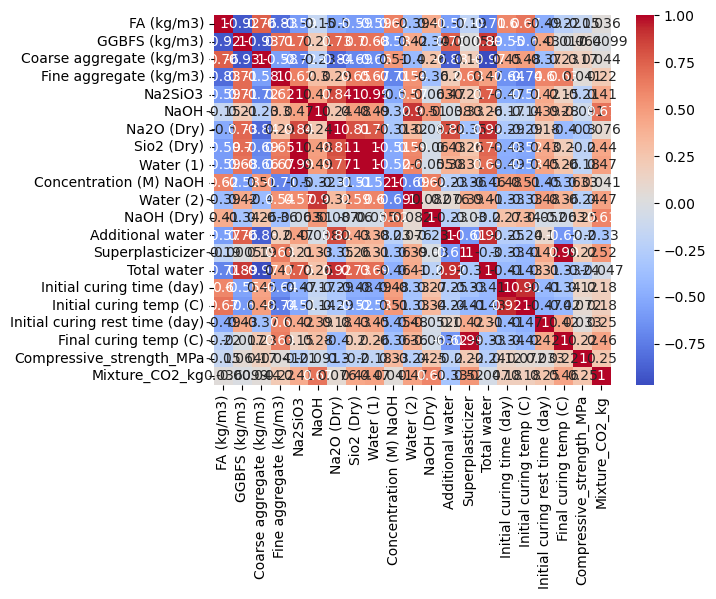

In [27]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm", annot=True)
plt.show()

In [28]:
corr = df.corr(numeric_only=True)
corr[corr.abs() > 0.5]

,FA (kg/m3),GGBFS (kg/m3),Coarse aggregate (kg/m3),Fine aggregate (kg/m3),Na2SiO3,NaOH,Na2O (Dry),Sio2 (Dry),Water (1),Concentration (M) NaOH,...,NaOH (Dry),Additional water,Superplasticizer,Total water,Initial curing time (day),Initial curing temp (C),Initial curing rest time (day),Final curing temp (C),Compressive_strength_MPa,Mixture_CO2_kg
FA (kg/m3),1.000000,-0.920220,0.756609,-0.828438,-0.593702,NaN,-0.502971,-0.592863,-0.588818,0.619880,...,NaN,-0.570928,NaN,-0.712178,0.599317,0.674308,NaN,NaN,NaN,NaN
GGBFS (kg/m3),-0.920220,1.000000,-0.925432,0.710663,0.713901,NaN,0.730223,0.701212,0.682784,-0.577420,...,NaN,0.758333,NaN,0.886180,-0.548579,-0.600259,NaN,NaN,NaN,NaN
Coarse aggregate (kg/m3),0.756609,-0.925432,1.000000,-0.575582,-0.715788,NaN,-0.838852,-0.693146,-0.663118,0.509933,...,NaN,-0.881387,NaN,-0.970074,NaN,NaN,NaN,NaN,NaN,NaN
Fine aggregate (kg/m3),-0.828438,0.710663,-0.575582,1.000000,0.624254,NaN,NaN,0.645249,0.667608,-0.708015,...,NaN,NaN,0.625486,NaN,-0.640368,-0.739787,0.603829,0.633507,NaN,NaN
Na2SiO3,-0.593702,0.713901,-0.715788,0.624254,1.000000,NaN,0.838062,0.998752,0.993910,-0.501968,...,NaN,NaN,NaN,0.756034,NaN,-0.508823,NaN,NaN,NaN,NaN
NaOH,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,0.514612,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.670184
Na2O (Dry),-0.502971,0.730223,-0.838852,NaN,0.838062,NaN,1.000000,0.809776,0.772842,NaN,...,NaN,0.819020,NaN,0.920016,NaN,NaN,NaN,NaN,NaN,NaN
Sio2 (Dry),-0.592863,0.701212,-0.693146,0.645249,0.998752,NaN,0.809776,1.000000,0.998171,-0.511477,...,NaN,NaN,NaN,0.728974,NaN,-0.520904,NaN,NaN,NaN,NaN
Water (1),-0.588818,0.682784,-0.663118,0.667608,0.993910,NaN,0.772842,0.998171,1.000000,-0.521331,...,NaN,NaN,NaN,0.693552,NaN,-0.532714,NaN,NaN,NaN,NaN
Concentration (M) NaOH,0.619880,-0.577420,0.509933,-0.708015,-0.501968,NaN,NaN,-0.511477,-0.521331,1.000000,...,0.624790,NaN,NaN,NaN,NaN,0.513977,NaN,NaN,NaN,NaN


In [29]:
df.corr(numeric_only=True)["Compressive_strength_MPa"].sort_values(ascending=False)


Compressive_strength_MPa          1.000000
Concentration (M) NaOH            0.332076
NaOH (Dry)                        0.251564
Mixture_CO2_kg                    0.249453
Final curing temp (C)             0.223828
Superplasticizer                  0.218928
Coarse aggregate (kg/m3)          0.166857
Initial curing time (day)         0.121708
Initial curing temp (C)           0.072222
GGBFS (kg/m3)                     0.064160
Fine aggregate (kg/m3)            0.041097
Initial curing rest time (day)    0.032751
NaOH                             -0.090657
FA (kg/m3)                       -0.146048
Water (1)                        -0.181754
Sio2 (Dry)                       -0.196749
Additional water                 -0.202027
Na2SiO3                          -0.208979
Water (2)                        -0.235211
Total water                      -0.240679
Na2O (Dry)                       -0.304092
Name: Compressive_strength_MPa, dtype: float64

In [30]:
df.corr(numeric_only=True)["Mixture_CO2_kg"].sort_values(ascending=False)


Mixture_CO2_kg                    1.000000
NaOH                              0.670184
NaOH (Dry)                        0.606122
Superplasticizer                  0.519819
Water (2)                         0.466165
Water (1)                         0.466103
Final curing temp (C)             0.460605
Sio2 (Dry)                        0.437556
Na2SiO3                           0.413710
Compressive_strength_MPa          0.249453
Initial curing rest time (day)    0.247882
Fine aggregate (kg/m3)            0.218920
Initial curing temp (C)           0.180684
Initial curing time (day)         0.179490
Na2O (Dry)                        0.075914
Coarse aggregate (kg/m3)          0.044065
Concentration (M) NaOH            0.040543
FA (kg/m3)                        0.035833
GGBFS (kg/m3)                    -0.009938
Total water                      -0.046643
Additional water                 -0.325786
Name: Mixture_CO2_kg, dtype: float64

In [31]:
# scatter dependency

In [32]:
labels = ['Mixture_CO2_kg', 'Compressive_strength_MPa']

features = df.drop( columns=labels)

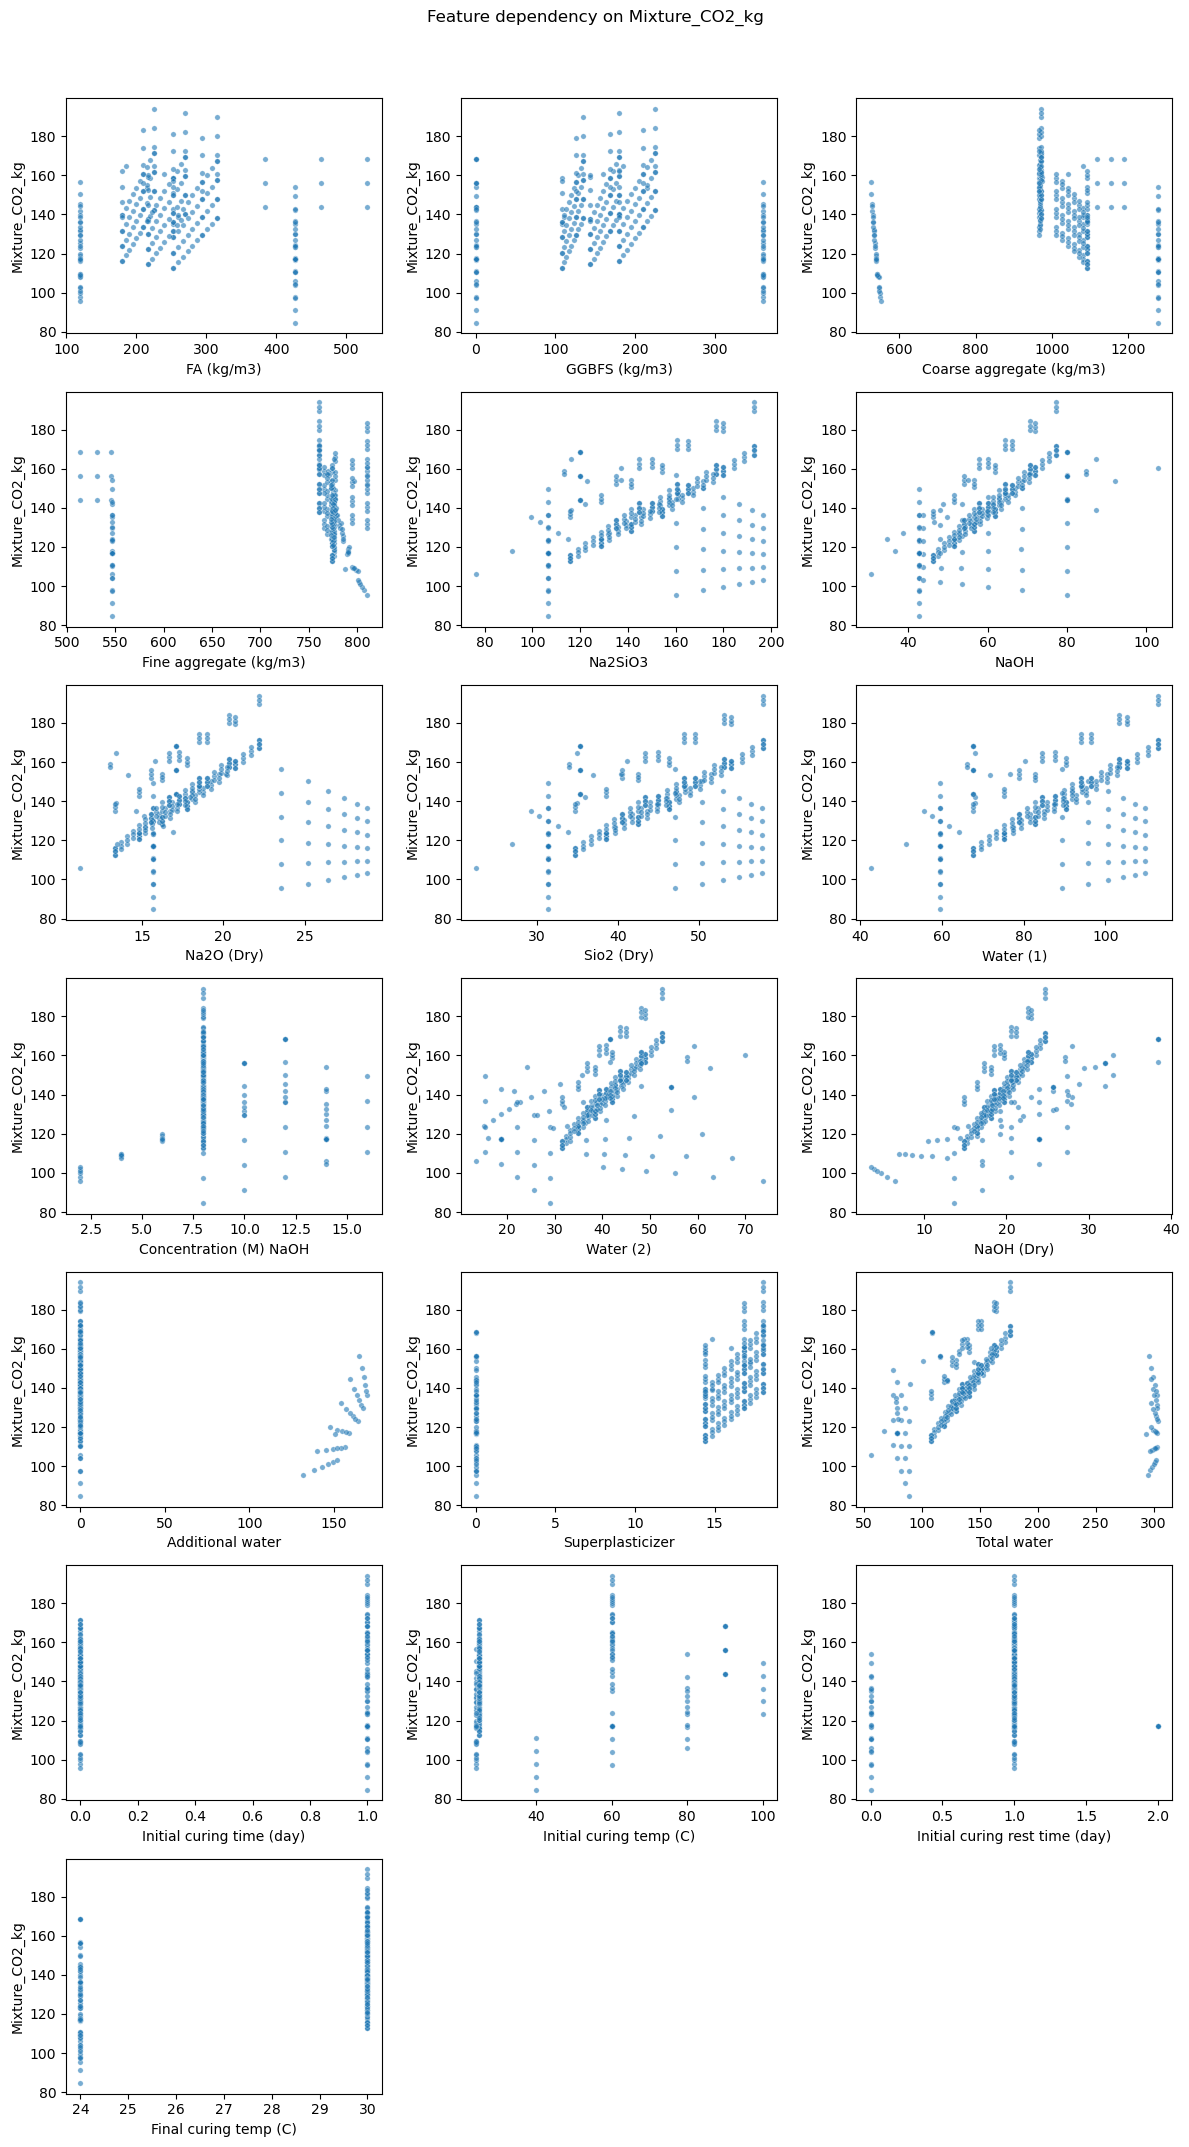

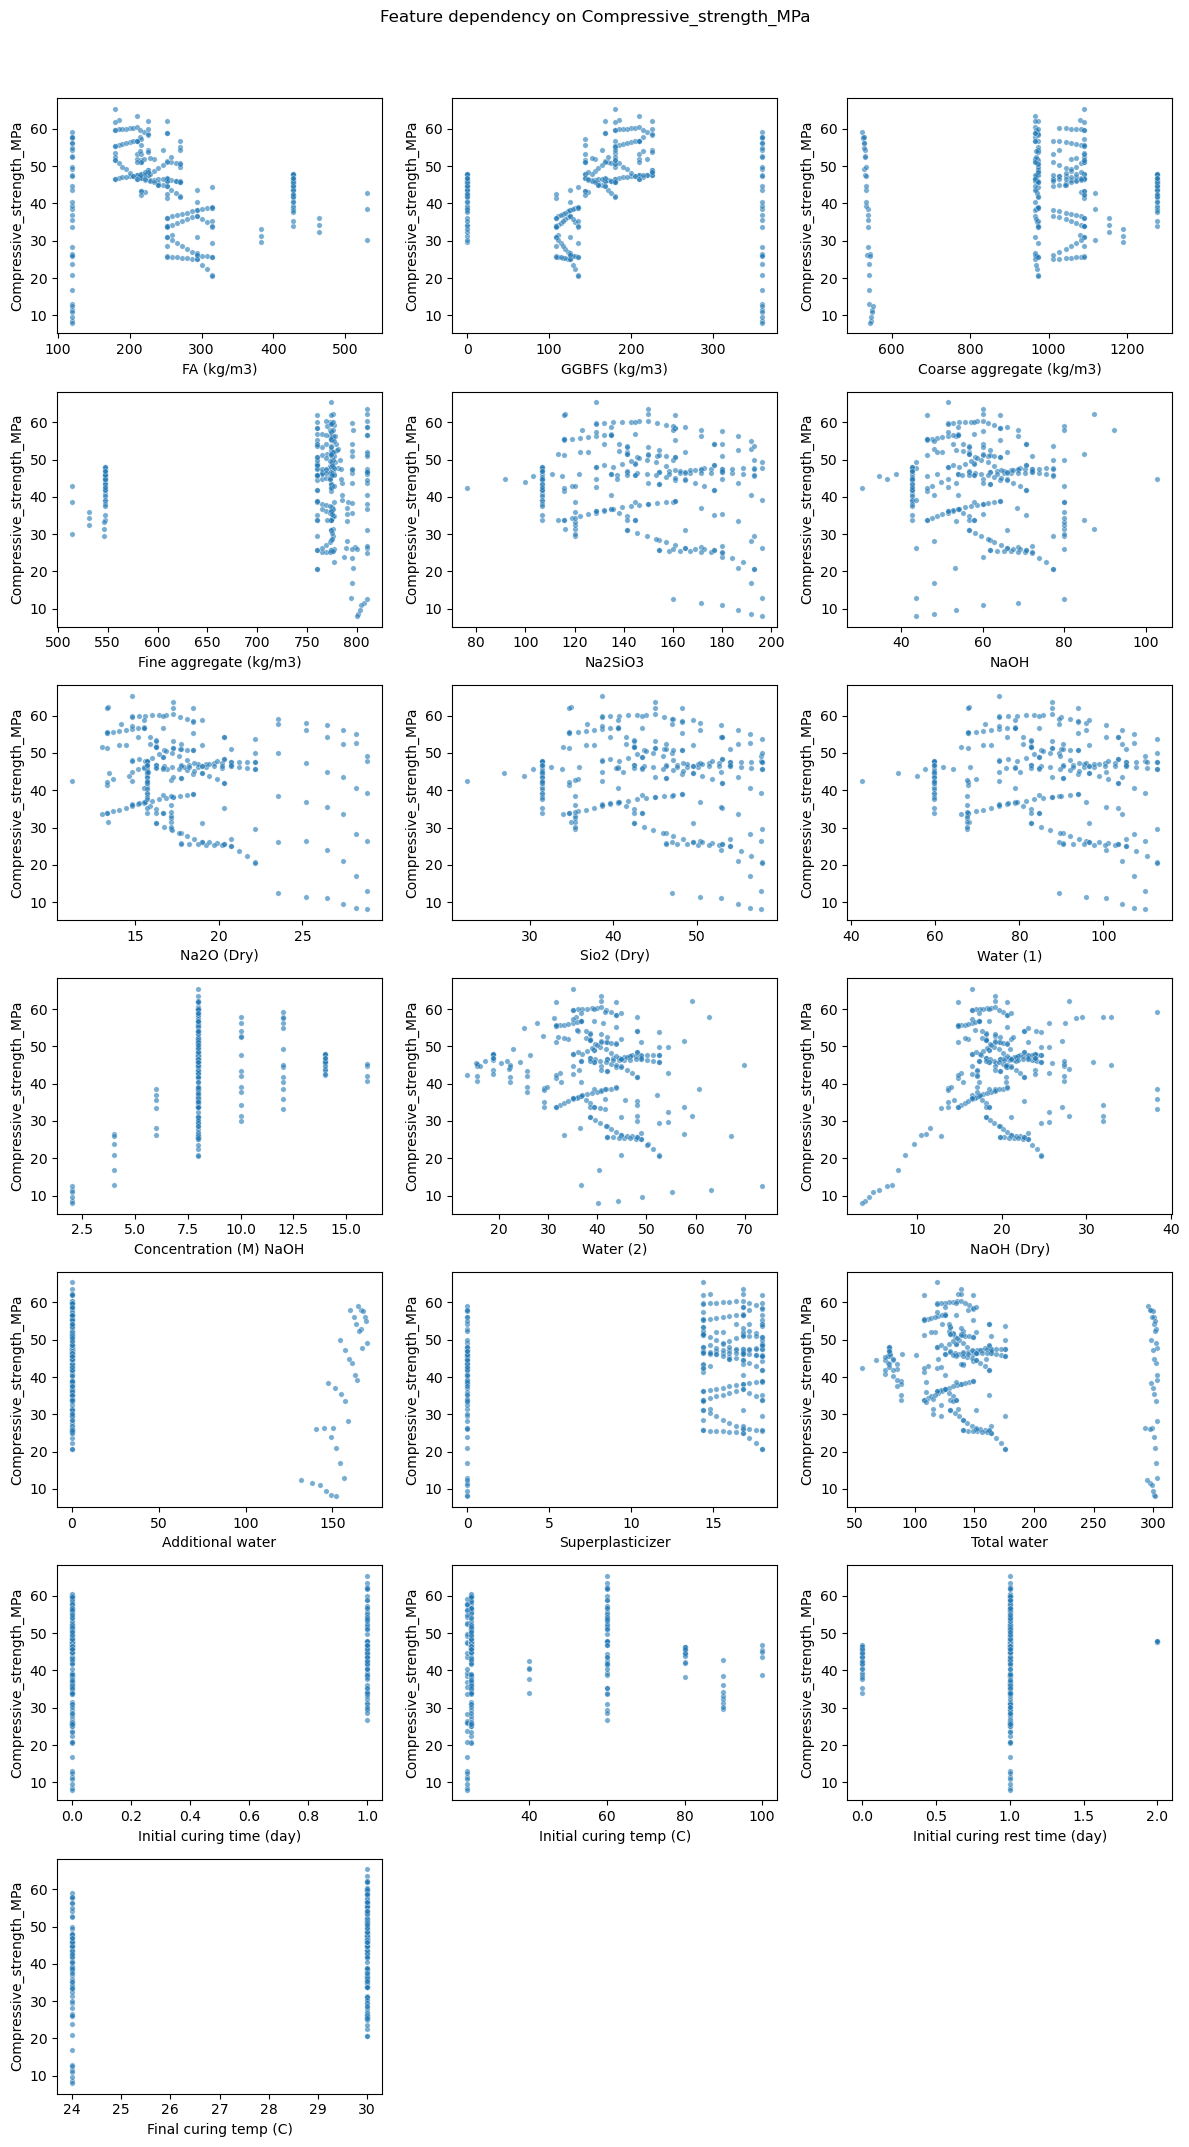

In [33]:
n_cols = 3

for target in labels:
    n_rows = math.ceil(len(features.columns) / n_cols)
    
    plt.figure(figsize=(4 * n_cols, 3 * n_rows))
    
    for i, col in enumerate(features.columns, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.scatterplot(
            data=df,
            x=col,
            y=target,
            s=15,
            alpha=0.6
        )
        plt.xlabel(col)
        plt.ylabel(target)
    
    plt.suptitle(f"Feature dependency on {target}", y=1.02)
    plt.tight_layout()
    plt.show()

# add new columns

In [34]:
corr = df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]


In [35]:
df['Water_to_Binder'] = df['Total water'] / (df['FA (kg/m3)'] + df['GGBFS (kg/m3)'])
df['Water_to_Activator'] = df['Total water'] / (df['NaOH'] + df['Na2SiO3'])
df['SP_ratio'] = df['Superplasticizer'] / df[['FA (kg/m3)', 'GGBFS (kg/m3)', 'Coarse aggregate (kg/m3)', 'Fine aggregate (kg/m3)']].sum(axis=1)


columns_to_drop = [
    "Water (1)", "Water (2)", "Additional water",
    "NaOH (Dry)", "Na2O (Dry)"
]

df.drop(columns=columns_to_drop, inplace=True)


df.head(2)

,FA (kg/m3),GGBFS (kg/m3),Coarse aggregate (kg/m3),Fine aggregate (kg/m3),Na2SiO3,NaOH,Sio2 (Dry),Concentration (M) NaOH,Superplasticizer,Total water,Initial curing time (day),Initial curing temp (C),Initial curing rest time (day),Final curing temp (C),Compressive_strength_MPa,Mixture_CO2_kg,Water_to_Binder,Water_to_Activator,SP_ratio
0,252.0,168.0,1010.929815,765.670185,180.000000,72.000000,54.00,8.0,16.8,164.340000,0.0,25.0,1.0,30.0,46.57,158.777280,0.391286,0.652143,0.007648
1,264.0,176.0,969.460026,777.339974,188.571429,75.428571,56.57,8.0,17.6,172.165714,0.0,25.0,1.0,30.0,46.01,165.788983,0.391286,0.652143,0.008048


In [16]:
# BASE_MIXING_CO2 = 3.83

# norm_paste_agg = df['paste_agg_ratio'] / df['paste_agg_ratio'].mean()
# norm_paste_agg = norm_paste_agg.clip(lower=0.5, upper=1.5)

# df['mixing_CO2_adj'] = BASE_MIXING_CO2 * (0.9 + 0.2 * norm_paste_agg)


# TRANSPORT_DISTANCE_KM = 50 
# TRANSPORT_EF = 0.1

# df['total_material_mass'] = (
#     df['cement'] +
#     df['fine_aggregate'] +
#     df['coarse_aggregate'] +
#     df['superplasticizer']
# )

# df['transport_CO2'] = (
#     (df['total_material_mass'] / 1000) *
#     TRANSPORT_DISTANCE_KM *
#     TRANSPORT_EF
# )



# df['total_CO2'] = (
#     df['embodied_CO2'] +
#     df['mixing_CO2_adj'] +
#     df['transport_CO2']
# )


In [17]:
df.head(2)

,cement,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength,embodied_CO2,energy_consumption,resource_consumption,...,agg_total,fine_coarse_ratio,total_mix_mass,paste,paste_agg_ratio,log_age,mixing_CO2_adj,total_material_mass,transport_CO2,total_CO2
0,312.362036,162.959305,7.851171,1001.810898,771.598763,51,344.476684,307.856482,1628.413117,2256.582173,...,1773.409662,0.770204,2256.582173,483.172511,0.272454,3.951244,4.089940,2093.622868,10.468114,322.414536
1,485.214292,187.933066,7.409364,1039.004419,841.629699,71,374.295933,468.240201,2418.001368,2561.190840,...,1880.634118,0.810035,2561.190840,680.556722,0.361876,4.276666,4.300959,2373.257774,11.866289,484.407449


In [18]:
# Distribution Analysis

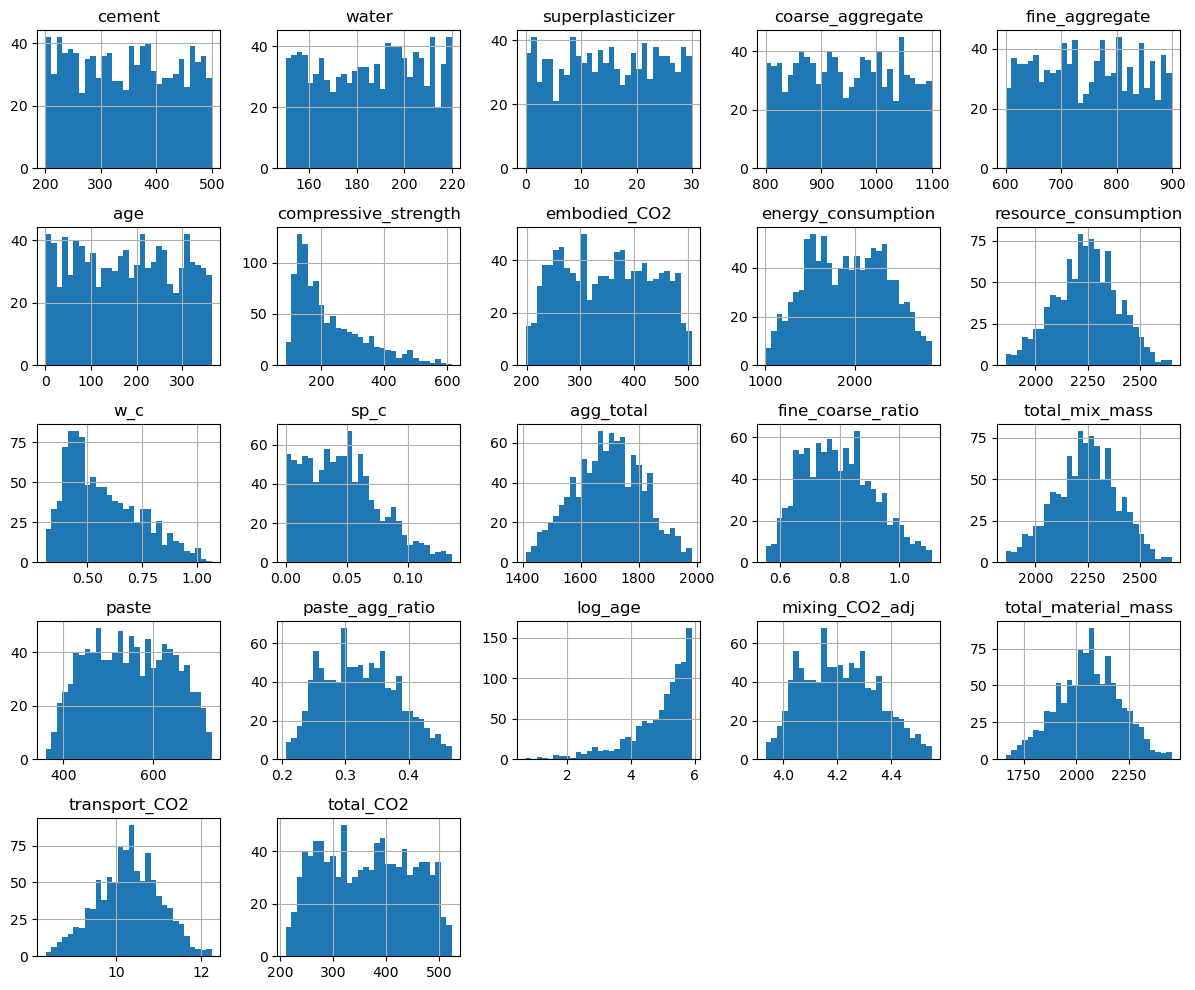

In [19]:
df.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()


In [20]:
# Outlier

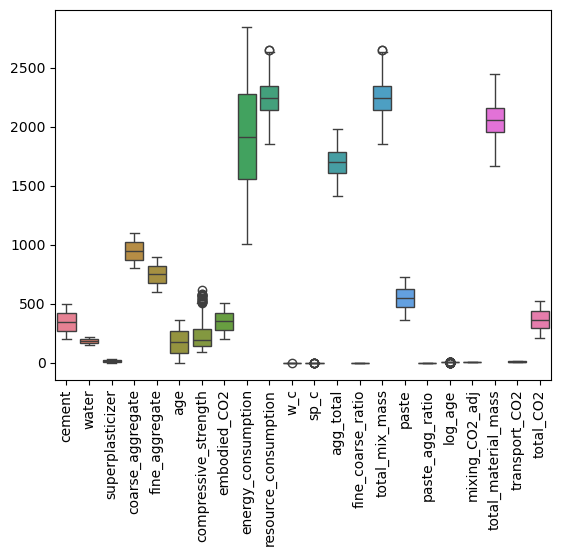

In [30]:
plt.figure()
sns.boxplot(data=df.select_dtypes("number"))
plt.xticks(rotation=90)
plt.show()


In [22]:
# sns.boxplot(x=df["compressive_strength"])


# preprocessing

In [23]:
y = df[labels]
y_log = np.log1p(y)

features = df.drop(columns=labels + ["age"], errors="ignore")

scale_features = features.columns.tolist()

In [24]:
scale_features

['cement',
 'water',
 'superplasticizer',
 'coarse_aggregate',
 'fine_aggregate',
 'w_c',
 'sp_c',
 'agg_total',
 'fine_coarse_ratio',
 'total_mix_mass',
 'paste',
 'paste_agg_ratio',
 'log_age',
 'mixing_CO2_adj',
 'total_material_mass',
 'transport_CO2',
 'total_CO2']

In [25]:
preprocessor = RobustScaler()

X_prepared = preprocessor.fit_transform(features)
X_prepared.shape


(1000, 17)

In [26]:
prepared_cols = preprocessor.get_feature_names_out()
X_prepared_df = pd.DataFrame(X_prepared, columns=prepared_cols, index=features.index)

X_prepared_df.head()

,cement,water,superplasticizer,coarse_aggregate,fine_aggregate,w_c,sp_c,agg_total,fine_coarse_ratio,total_mix_mass,paste,paste_agg_ratio,log_age,mixing_CO2_adj,total_material_mass,transport_CO2,total_CO2
0,-0.240520,-0.642293,-0.479974,0.380162,0.156353,-0.046688,-0.436603,0.431143,-0.099284,0.044236,-0.418749,-0.531015,-1.088798,-0.531015,0.161584,0.161584,-0.305478
1,0.892909,0.044604,-0.509561,0.630300,0.627923,-0.585870,-0.662656,1.045435,0.125640,1.559447,0.871347,0.452243,-0.804719,0.452243,1.537457,1.537457,0.825670
2,0.462650,0.681976,0.814944,-0.471736,0.536469,-0.121257,0.472228,0.028846,0.894501,0.564041,0.723211,0.720478,-1.140672,0.720478,0.438848,0.438848,0.594596
3,0.200358,0.411041,-0.504403,0.283663,-0.688252,-0.012656,-0.560644,-0.369645,-0.753372,-0.127926,0.268620,0.433175,-1.922919,0.433175,-0.197135,-0.197135,0.124123
4,-0.670387,0.554163,-0.459393,0.176472,-0.697647,1.216506,-0.255075,-0.468949,-0.700858,-0.845466,-0.560901,-0.387768,0.326186,-0.387768,-0.932483,-0.932483,-0.738082


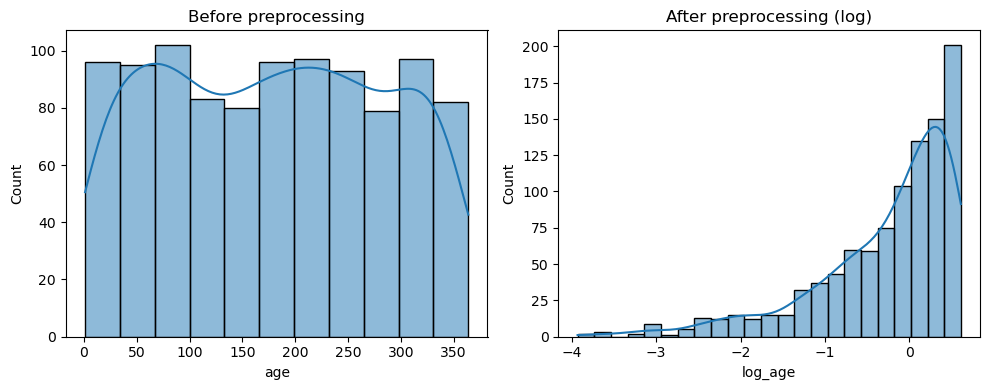

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df[col], kde=True, ax=axes[0])
axes[0].set_title("Before preprocessing")
axes[0].set_xlabel(col)

sns.histplot(X_prepared_df["log_age"], kde=True, ax=axes[1])
axes[1].set_title("After preprocessing (log)")
axes[1].set_xlabel("log_age")

plt.tight_layout()
plt.show()

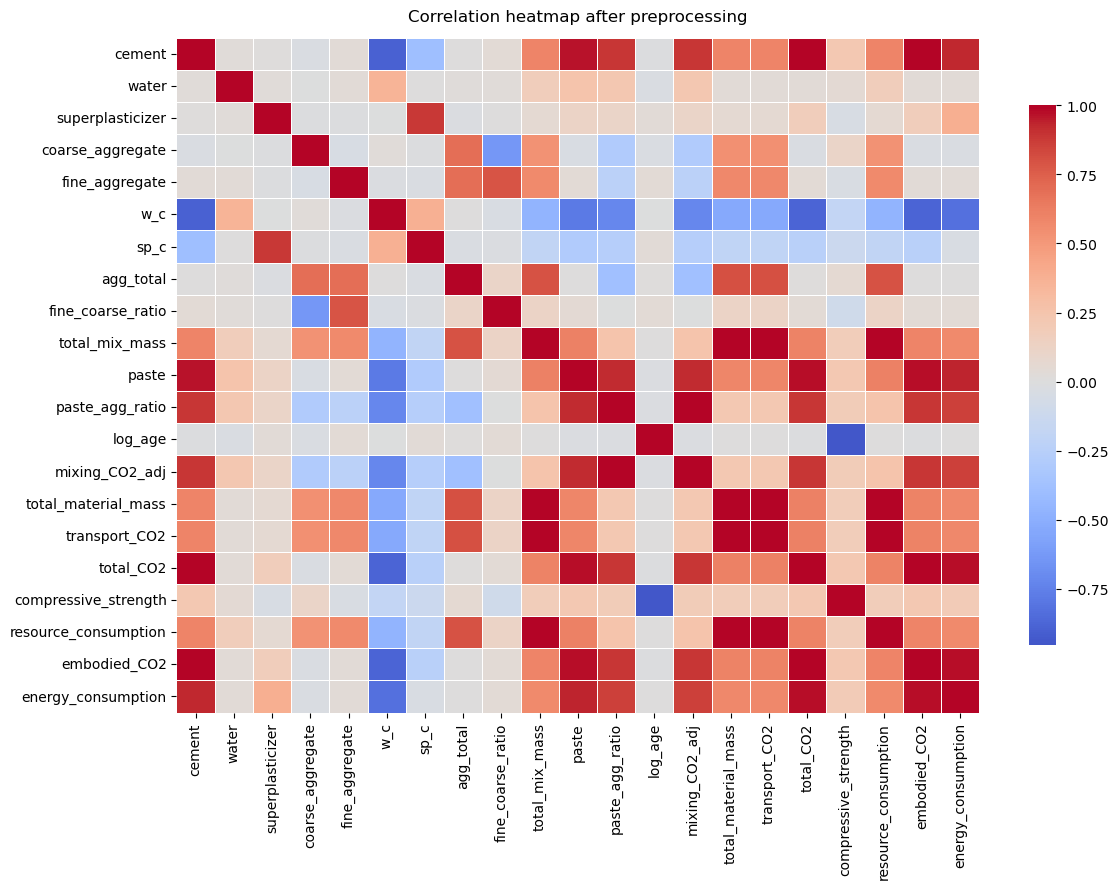

In [28]:
heatmap_df = pd.concat(
    [X_prepared_df, y], axis=1
)

corr = heatmap_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation heatmap after preprocessing", pad=12)
plt.tight_layout()
plt.show()

# save data

In [29]:
os.makedirs("../data", exist_ok=True)

prepared_data = pd.concat([X_prepared_df, y], axis=1)

prepared_data.to_csv("../data/preprocessed_dataset.csv", index=False)